# Customer Churn Analysis for Telecommunications Company

This notebook contains the complete project workflow: data loading, preprocessing, clustering analysis, ANN churn prediction, evaluation, and business interpretation.

## 1. Setup and Library Imports

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "outputs/.matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)

DATA_PATH = Path("Dataset_ATS_v2.csv")
PREPROCESSING_DIR = Path("preprocessing")
CLUSTERS_DIR = Path("clusters")
MODEL_DIR = Path("model_outputs")

for folder in [PREPROCESSING_DIR, CLUSTERS_DIR, MODEL_DIR]:
    folder.mkdir(exist_ok=True)

## 2. Load Dataset and Check Data Integrity

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
for column in [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]:
    df[column] = df[column].astype(str).str.strip()

df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["SeniorCitizen"] = pd.to_numeric(df["SeniorCitizen"], errors="coerce").astype("Int64")

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.isna().sum())

Shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   Int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: Int64(1), int64(2), object(7)
memory usage: 557.2+ KB


None

gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64

## 3. Exploratory Churn Analysis

In [3]:
overall_churn = df["Churn"].eq("Yes").mean()
print(f"Overall churn rate: {overall_churn:.2%}")

for column in ["SeniorCitizen", "Dependents", "Contract", "InternetService", "PhoneService", "MultipleLines", "gender"]:
    summary = df.groupby(column)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
    print(f"\nChurn rate by {column}")
    display((summary * 100).round(2).rename("Churn Rate %"))

Overall churn rate: 26.54%

Churn rate by SeniorCitizen


SeniorCitizen
1    41.68
0    23.61
Name: Churn Rate %, dtype: float64


Churn rate by Dependents


Dependents
No     31.28
Yes    15.45
Name: Churn Rate %, dtype: float64


Churn rate by Contract


...

PhoneService
Yes    26.71
No     24.93
Name: Churn Rate %, dtype: float64


Churn rate by MultipleLines


MultipleLines
No     26.55
Yes    26.52
Name: Churn Rate %, dtype: float64


Churn rate by gender


gender
Female    26.92
Male      26.16
Name: Churn Rate %, dtype: float64

## 4. Data Preprocessing

Preprocessing is performed inside the notebook. The original CSV is not manually edited in Excel.

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Copy original dataset
prepared_df = df.copy()

# Separate features and target
X = prepared_df.drop(columns=["Churn"])
y = prepared_df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# Identify feature types
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

# Numeric preprocessing:
# Missing values -> median calculated from training data
# Scaling -> fitted on training data
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# Missing values -> most frequent value from training data
# Encoding -> fitted on training data
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# ============================================================
# SPLIT FIRST
# ============================================================

x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# ============================================================
# FIT PREPROCESSING ONLY ON TRAINING DATA
# ============================================================

x_train_encoded = preprocessor.fit_transform(x_train_raw)

# ============================================================
# TRANSFORM TEST DATA USING TRAINING PARAMETERS
# ============================================================

x_test_encoded = preprocessor.transform(x_test_raw)

# Get feature names
feature_names = (
    numeric_features
    + list(
        preprocessor
        .named_transformers_["cat"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
    )
)

# Create training and testing DataFrames
train_df = pd.DataFrame(
    x_train_encoded,
    columns=feature_names,
    index=x_train_raw.index
)

test_df = pd.DataFrame(
    x_test_encoded,
    columns=feature_names,
    index=x_test_raw.index
)

train_df["Churn"] = y_train
test_df["Churn"] = y_test

# ============================================================
# SAVE TRAINING AND TESTING DATASETS
# ============================================================

train_df.to_csv(
    PREPROCESSING_DIR / "train_dataset.csv",
    index=False
)

test_df.to_csv(
    PREPROCESSING_DIR / "test_dataset.csv",
    index=False
)

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)
print("Preprocessing fitted only on training data.")

Training set: (5634, 11)
Testing set: (1409, 11)
Preprocessing fitted only on training data.


## 5. Clustering Analysis

K-Means is used to segment customers. The elbow method helps justify the selected number of clusters.

Clustering dataset shape: (7043, 10)


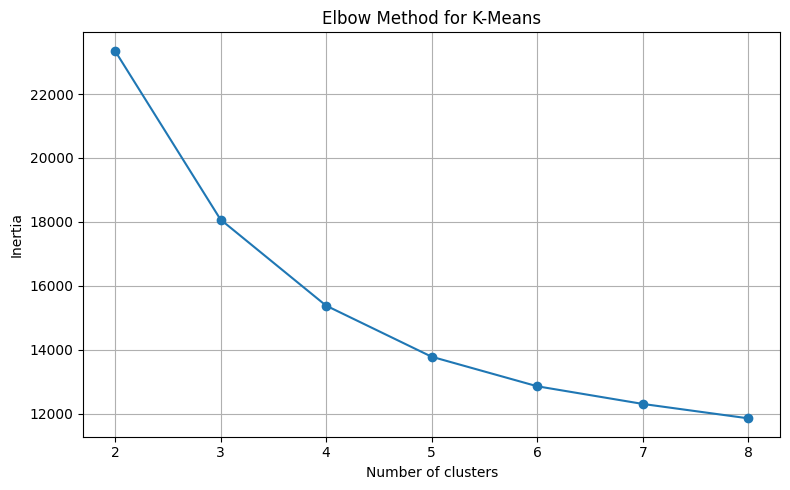

In [5]:

x_cluster = preprocessor.transform(X)

print("Clustering dataset shape:", x_cluster.shape)

# Elbow Method
inertias = []
k_values = range(2, 9)

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    
    kmeans_model.fit(x_cluster)
    inertias.append(kmeans_model.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CLUSTERS_DIR / "elbow_method.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [6]:
selected_k = 4
kmeans = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=20)
labels = kmeans.fit_predict(x_cluster)

clustered = prepared_df.copy()
clustered["Cluster"] = labels
clustered.to_csv(CLUSTERS_DIR / "cluster_assignments.csv", index=False)

cluster_profiles = clustered.groupby("Cluster").agg(
    customers=("Churn", "size"),
    churn_rate=("Churn", lambda s: (s == "Yes").mean()),
    avg_tenure=("tenure", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean"),
    senior_share=("SeniorCitizen", "mean"),
)
cluster_profiles.to_csv(CLUSTERS_DIR / "cluster_profiles.csv")
display(cluster_profiles)

,customers,churn_rate,avg_tenure,avg_monthly_charges,senior_share
Cluster,,,,,
0,1979,0.107125,29.326427,25.765538,0.0
1,2116,0.445180,12.547259,73.204631,0.0
2,1806,0.132337,58.349391,88.069767,0.0
3,1142,0.416813,33.295972,79.816988,1.0


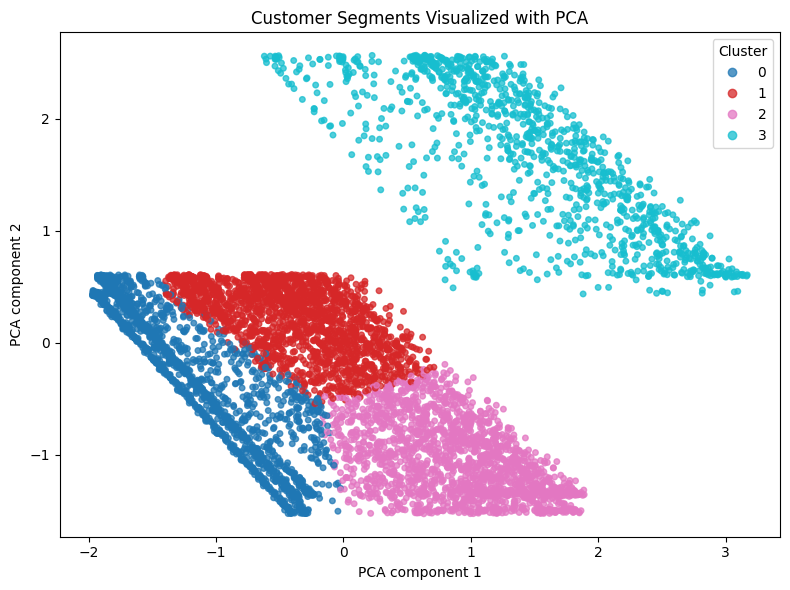

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
points = pca.fit_transform(x_cluster)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(points[:, 0], points[:, 1], c=labels, cmap="tab10", s=16, alpha=0.75)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Customer Segments Visualized with PCA")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.savefig(CLUSTERS_DIR / "clusters_pca.png", dpi=160)
plt.show()

## 6. ANN Churn Prediction

In [8]:
# Prepare training and testing data for ANN
X_train = train_df.drop(columns=["Churn"])
X_test = test_df.drop(columns=["Churn"])

Y_train = train_df["Churn"]
Y_test = test_df["Churn"]

# Build ANN model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dropout(0.10),
    Dense(1, activation="sigmoid"),
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train.to_numpy(),
    Y_train.to_numpy(),
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

# Make predictions
probabilities = model.predict(
    X_test.to_numpy(),
    verbose=0
).ravel()

predictions = (probabilities >= 0.5).astype(int)

# Evaluate model
metrics = {
    "accuracy": accuracy_score(Y_test, predictions),
    "precision": precision_score(Y_test, predictions),
    "recall": recall_score(Y_test, predictions),
    "roc_auc": roc_auc_score(Y_test, probabilities),
}

display(pd.Series(metrics).round(4))

print(classification_report(Y_test, predictions))

accuracy     0.7814
precision    0.6187
recall       0.4599
roc_auc      0.8075
dtype: float64

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.46      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



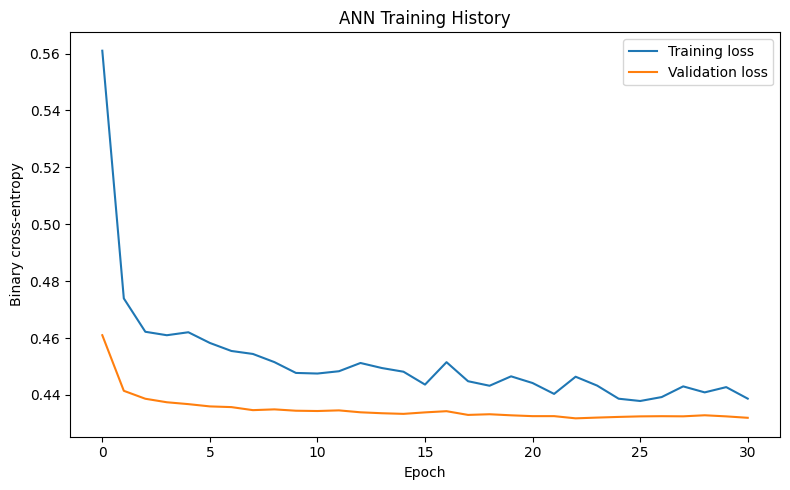

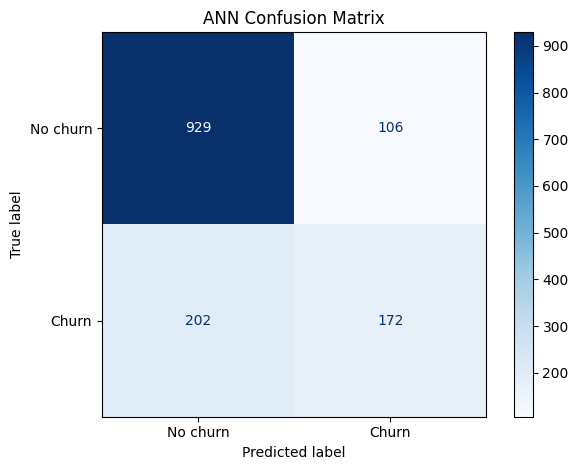

In [9]:
pd.DataFrame({
    "actual_churn": y_test.values,
    "predicted_churn": predictions,
    "churn_probability": probabilities,
}).to_csv(MODEL_DIR / "ann_predictions.csv", index=False)

model.save(MODEL_DIR / "ann_model.keras")

with open(MODEL_DIR / "metrics_summary.txt", "w", encoding="utf-8") as f:
    for key, value in metrics.items():
        f.write(f"{key}: {value:.4f}\n")
    f.write("\nClassification report:\n")
    f.write(classification_report(y_test, predictions))

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("ANN Training History")
plt.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "ann_training_history.png", dpi=160)
plt.show()

cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"]).plot(values_format="d", cmap="Blues")
plt.title("ANN Confusion Matrix")
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrix.png", dpi=160)
plt.show()

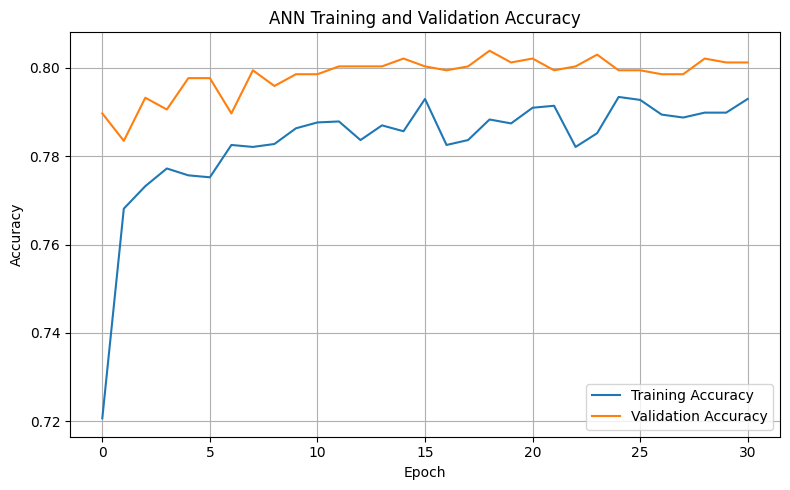

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    MODEL_DIR / "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

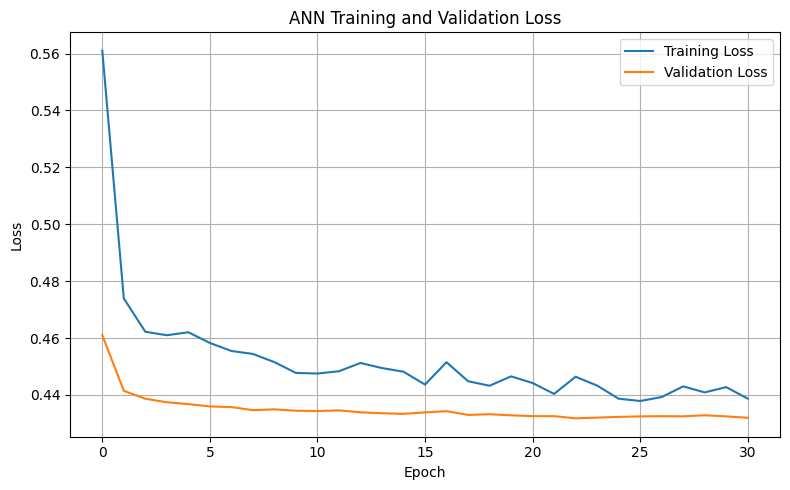

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    MODEL_DIR / "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model.save(
    MODEL_DIR / "ann_model.keras"
)

prediction_results = X_test.copy()

prediction_results["Actual_Churn"] = y_test.values
prediction_results["Churn_Probability"] = probabilities
prediction_results["Predicted_Churn"] = predictions

prediction_results.to_csv(
    MODEL_DIR / "ann_predictions.csv",
    index=False
)

with open(MODEL_DIR / "model_metrics.txt", "w") as f:
    for metric, value in metrics.items():
        f.write(f"{metric}: {value:.4f}\n")

## 7. Business Interpretation

The analysis indicates that short-tenure customers and customers with higher monthly charges are the strongest observed churn-risk groups. Senior customers and customers without dependents also show elevated churn rates. Retention efforts should therefore prioritise first-year onboarding, high-charge customer plan and billing reviews, targeted support for higher-risk customer groups, and human-reviewed outreach using ANN churn probabilities.